In [1]:
import torch
import numpy as np
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [2]:
import pandas as pd

# Load BTC CSV
btc_df = pd.read_csv(r'feature_datasets\BTC_features.csv', parse_dates=True, index_col=0)

# Define X and y
btc_y = btc_df['Close'].shift(-1)          # next-day close price
btc_X = btc_df.drop(columns=['Close'])     # all other features

# Drop last row (y will be NaN)
btc_X = btc_X.iloc[:-1]
btc_y = btc_y.iloc[:-1]

# check shapes
print("BTC X shape:", btc_X.shape)
print("BTC y shape:", btc_y.shape)

BTC X shape: (915, 29)
BTC y shape: (915,)


## Basic 70-30 split

In [3]:
# 70% train / 30% test split (time-based)
split_idx = int(len(btc_X) * 0.7)

btc_X_train = btc_X.iloc[:split_idx].values
btc_X_test  = btc_X.iloc[split_idx:].values

btc_y_train = btc_y.iloc[:split_idx].values
btc_y_test  = btc_y.iloc[split_idx:].values

# Optional: check shapes
print("BTC X_train shape:", btc_X_train.shape)
print("BTC X_test shape:", btc_X_test.shape)
print("BTC y_train shape:", btc_y_train.shape)
print("BTC y_test shape:", btc_y_test.shape)

BTC X_train shape: (640, 29)
BTC X_test shape: (275, 29)
BTC y_train shape: (640,)
BTC y_test shape: (275,)


In [4]:
# ! pip install --upgrade pip

In [5]:
# pip install scikit-learn

In [ ]:
btc_test_dates = btc_df.index[-len(btc_X_test):]  # get the dates for test set

In [7]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Initialize scaler
scaler = MinMaxScaler()

# Fit on TRAIN only
btc_X_train_scaled = scaler.fit_transform(btc_X_train)

# Transform TEST using the same scaler
btc_X_test_scaled = scaler.transform(btc_X_test)

# Check shapes
print("Scaled X_train shape:", btc_X_train_scaled.shape)
print("Scaled X_test shape:", btc_X_test_scaled.shape)

Scaled X_train shape: (640, 29)
Scaled X_test shape: (275, 29)


In [8]:
# Initialize scaler for y
y_scaler = MinMaxScaler()

# Scale training target
btc_y_train_scaled = y_scaler.fit_transform(btc_y_train.reshape(-1,1)).flatten()

# Scale test target
btc_y_test_scaled = y_scaler.transform(btc_y_test.reshape(-1,1)).flatten()

In [10]:
def create_sequences(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])  # the next day after the sequence
    return np.array(X_seq), np.array(y_seq)

# Create sequences for BTC using scaled target
btc_X_train_seq, btc_y_train_seq = create_sequences(btc_X_train_scaled, btc_y_train_scaled, time_steps=30)
btc_X_test_seq, btc_y_test_seq = create_sequences(btc_X_test_scaled, btc_y_test_scaled, time_steps=30)

# Check shapes
print("BTC X_train_seq shape:", btc_X_train_seq.shape)
print("BTC y_train_seq shape:", btc_y_train_seq.shape)
print("BTC X_test_seq shape:", btc_X_test_seq.shape)
print("BTC y_test_seq shape:", btc_y_test_seq.shape)

BTC X_train_seq shape: (610, 30, 29)
BTC y_train_seq shape: (610,)
BTC X_test_seq shape: (245, 30, 29)
BTC y_test_seq shape: (245,)


### Training the model for the basic split

In [11]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [12]:
# Get number of features from the sequences
input_size = btc_X_train_seq.shape[2]

# Initialize Bi-LSTM model
model = BiLSTM(input_size=input_size)

In [13]:
model = train_model(
    model,
    btc_X_train_seq,
    btc_y_train_seq,
    epochs=50,       
    batch_size=32,
    lr=0.001
)

Epoch [10/50], Loss: 0.001901
Epoch [20/50], Loss: 0.001390
Epoch [30/50], Loss: 0.001326
Epoch [40/50], Loss: 0.001667
Epoch [50/50], Loss: 0.005294


In [14]:
btc_preds = predict_model(model, btc_X_test_seq)

# Optional: check
print("Predictions shape:", btc_preds.shape)
print("First 10 predictions:", btc_preds[:10])

Predictions shape: (245, 1)
First 10 predictions: [[0.27539834]
 [0.26059785]
 [0.24995986]
 [0.24077538]
 [0.23506346]
 [0.23139362]
 [0.22953196]
 [0.22272998]
 [0.21439852]
 [0.21083865]]


In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Inverse scale predictions
btc_preds_actual = y_scaler.inverse_transform(btc_preds.reshape(-1,1))

# Skip first 30 because of 30-day sequence
btc_y_test_actual = btc_y_test[30:].reshape(-1,1)

# Calculate metrics
mse = mean_squared_error(btc_y_test_actual, btc_preds_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(btc_y_test_actual, btc_preds_actual)
r2 = r2_score(btc_y_test_actual, btc_preds_actual)
mape = np.mean(np.abs((btc_y_test_actual - btc_preds_actual) / btc_y_test_actual)) * 100

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MSE: 1302692.28
RMSE: 1141.36
MAE: 856.03
R2 Score: 0.9577
MAPE: 2.70%


In [16]:
btc_preds_actual = y_scaler.inverse_transform(btc_preds.reshape(-1,1))

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Skip first 30 because of sequence
dates_seq = btc_df.index[-len(btc_X_test):][30:]  # test dates aligned with sequences
actual_seq = btc_y_test[30:]                      # actual prices aligned
pred_seq = btc_preds_actual                       # predicted prices aligned

# Create DataFrame
df_plot = pd.DataFrame({
    "Date": dates_seq,
    "Actual": actual_seq,
    "Predicted": pred_seq.flatten()
})

df_plot.set_index("Date", inplace=True)
df_plot

,Actual,Predicted
Date,,
2023-05-02,28680.537109,30047.285156
2023-05-03,29006.308594,29280.921875
2023-05-04,28847.710938,28730.091797
2023-05-05,29534.384766,28254.523438
2023-05-06,28904.623047,27958.763672
...,...,...
2023-12-28,42627.855469,41195.597656
2023-12-29,42099.402344,41538.675781
2023-12-30,42156.902344,41959.277344


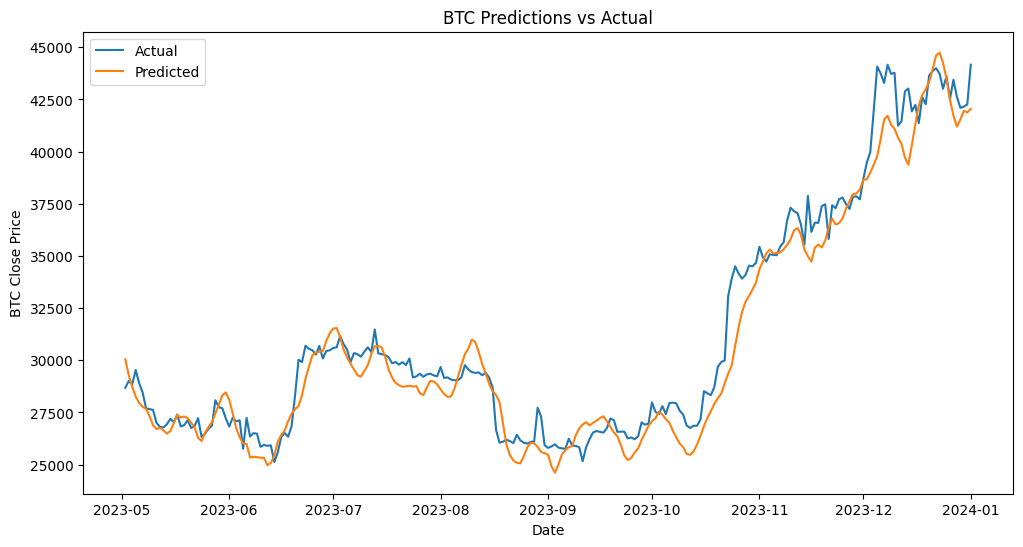

In [18]:
plt.figure(figsize=(12,6))
plt.plot(df_plot["Actual"], label="Actual")
plt.plot(df_plot["Predicted"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("BTC Close Price")
plt.title("BTC Predictions vs Actual")
plt.legend()
plt.show()

## Each year 70% train split

### Preparing the train and test datasets

In [19]:
# Get unique years from your DataFrame index
years = btc_df.index.year.unique()
print("Years in dataset:", years)

Years in dataset: Index([2021, 2022, 2023, 2024], dtype='int32', name='Date')


In [20]:
X_train_list = []
y_train_list = []

In [21]:
for year in years:
    # Filter data for this year
    btc_year = btc_df[btc_df.index.year == year]

    # Calculate split index for 70%
    split_idx = int(len(btc_year) * 0.7)

    # Take first 70% as training
    X_train_year = btc_year.iloc[:split_idx, 1:].values  # all features except target column
    y_train_year = btc_year.iloc[:split_idx, 0].values   # target column (e.g., next-day Close)

    # Append to lists
    X_train_list.append(X_train_year)
    y_train_list.append(y_train_year)

    print(f"Year {year}: {len(X_train_year)} train samples")

Year 2021: 129 train samples
Year 2022: 255 train samples
Year 2023: 255 train samples
Year 2024: 0 train samples


In [22]:
import numpy as np

# Stack all years’ train sets
X_train_combined = np.vstack(X_train_list)
y_train_combined = np.hstack(y_train_list)

print("Combined X_train shape:", X_train_combined.shape)
print("Combined y_train shape:", y_train_combined.shape)

Combined X_train shape: (639, 29)
Combined y_train shape: (639,)


In [23]:
X_test_list = []
y_test_list = []

In [24]:
for year in years:
    btc_year = btc_df[btc_df.index.year == year]

    # Calculate split index (same as for train)
    split_idx = max(1, int(len(btc_year) * 0.7))  # ensures at least 1 sample in train

    # Take the remaining 30% as test
    X_test_year = btc_year.iloc[split_idx:, 1:].values   # features
    y_test_year = btc_year.iloc[split_idx:, 0].values    # target

    # Append to test lists
    X_test_list.append(X_test_year)
    y_test_list.append(y_test_year)

    print(f"Year {year}: {len(X_test_year)} test samples")


Year 2021: 56 test samples
Year 2022: 110 test samples
Year 2023: 110 test samples
Year 2024: 0 test samples


In [25]:
import numpy as np

X_test_combined = np.vstack(X_test_list)
y_test_combined = np.hstack(y_test_list)

print("Combined X_test shape:", X_test_combined.shape)
print("Combined y_test shape:", y_test_combined.shape)

Combined X_test shape: (276, 29)
Combined y_test shape: (276,)


In [26]:
from sklearn.preprocessing import MinMaxScaler

# Initialize scalers
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

# Scale training data
X_train_scaled = x_scaler.fit_transform(X_train_combined)
y_train_scaled = y_scaler.fit_transform(y_train_combined.reshape(-1,1)).flatten()

In [27]:
import joblib

joblib.dump(x_scaler,"btc_x_scaler.pkl")
joblib.dump(y_scaler,"btc_y_scaler.pkl")

['btc_y_scaler.pkl']

In [28]:
X_test_scaled = x_scaler.transform(X_test_combined)
y_test_scaled = y_scaler.transform(y_test_combined.reshape(-1,1)).flatten()

In [ ]:
print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)
print("Scaled y_train shape:", y_train_scaled.shape)
print("Scaled y_test shape:", y_test_scaled.shape)

Scaled X_train shape: (639, 29)
Scaled X_test shape: (276, 29)
Scaled y_train shape: (639,)
Scaled y_test shape: (276,)


In [30]:
import numpy as np

def create_sequences(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])  # the next day after the sequence
    return np.array(X_seq), np.array(y_seq)

# Create sequences for train and test
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled)

# Check shapes
print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)
print("X_test_seq shape:", X_test_seq.shape)
print("y_test_seq shape:", y_test_seq.shape)

X_train_seq shape: (609, 30, 29)
y_train_seq shape: (609,)
X_test_seq shape: (246, 30, 29)
y_test_seq shape: (246,)


### Training the model for each year 70% train

In [31]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [32]:
# Get number of features from the sequences
input_size = X_train_seq.shape[2]   # use the combined train sequences

# Initialize Bi-LSTM model
model_y = BiLSTM(input_size=input_size)

In [33]:
model_y = train_model(model_y, X_train_seq, y_train_seq, epochs=50, batch_size=32, lr=0.001)

c:\Users\tharu\anaconda3\envs\Streamlit\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [10/50], Loss: 0.002753
Epoch [20/50], Loss: 0.007031
Epoch [30/50], Loss: 0.003123
Epoch [40/50], Loss: 0.001730
Epoch [50/50], Loss: 0.000939


In [34]:
btc_preds_ev_year = predict_model(model_y, X_test_seq)
btc_preds_ev_year[:10]

array([[0.77494395],
       [0.7663516 ],
       [0.77300286],
       [0.7731627 ],
       [0.75792044],
       [0.7330266 ],
       [0.7253796 ],
       [0.7296882 ],
       [0.7130374 ],
       [0.69561386]], dtype=float32)

In [35]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predict using the trained model
btc_preds_ev_year = predict_model(model_y, X_test_seq)

# Inverse scale predictions to original price values
btc_preds_actual = y_scaler.inverse_transform(btc_preds_ev_year.reshape(-1,1))

# Inverse scale the test targets
btc_y_test_actual = y_scaler.inverse_transform(y_test_seq.reshape(-1,1))

# Calculate metrics
mse = mean_squared_error(btc_y_test_actual, btc_preds_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(btc_y_test_actual, btc_preds_actual)
r2 = r2_score(btc_y_test_actual, btc_preds_actual)
mape = np.mean(np.abs((btc_y_test_actual - btc_preds_actual) / btc_y_test_actual)) * 100

# Print results
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MSE: 7634530.43
RMSE: 2763.07
MAE: 1417.17
R2 Score: 0.9389
MAPE: 4.93%


In [36]:
btc_preds_actual = y_scaler.inverse_transform(btc_preds_ev_year.reshape(-1, 1))

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Actual and predicted prices
actual_test_seq = y_scaler.inverse_transform(y_test_seq.reshape(-1,1)).flatten()
predicted_test_seq = btc_preds_actual.flatten()

# Create DataFrame for plotting (no Date index)
df_btc_plot_year = pd.DataFrame({
    "Actual": actual_test_seq,
    "Predicted": predicted_test_seq
})

# Display first few rows
df_btc_plot_year.head()

,Actual,Predicted
0,50582.625000,54882.324219
1,50700.085938,54458.140625
2,50504.796875,54786.500000
3,47672.121094,54794.390625
4,47243.304688,54041.910156


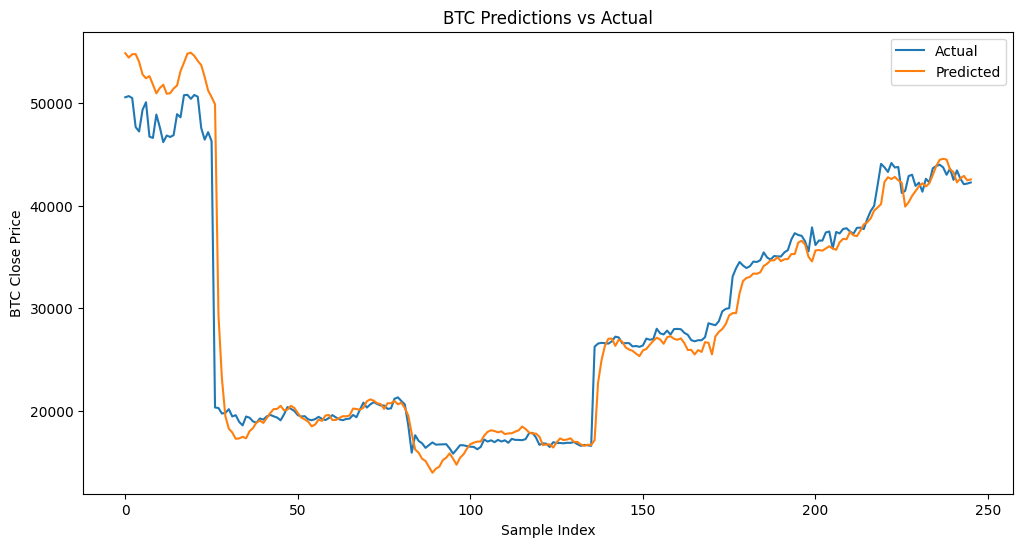

In [38]:
# Plot
plt.figure(figsize=(12,6))
plt.plot(df_btc_plot_year["Actual"], label="Actual")
plt.plot(df_btc_plot_year["Predicted"], label="Predicted")
plt.xlabel("Sample Index")
plt.ylabel("BTC Close Price")
plt.title("BTC Predictions vs Actual")
plt.legend()
plt.show()

## Three quarters train (all years-75%)

### Preparing the train and test datasets

In [38]:
# 75% train / 25% test split (time-based)
q3_split_idx = int(len(btc_X) * 0.75)

btc_q3_X_train = btc_X.iloc[:q3_split_idx].values
btc_q3_X_test  = btc_X.iloc[q3_split_idx:].values

btc_q3_y_train = btc_y.iloc[:q3_split_idx].values
btc_q3_y_test  = btc_y.iloc[q3_split_idx:].values

# Shape checks
print("Q3 BTC X_train shape:", btc_q3_X_train.shape)
print("Q3 BTC X_test shape:", btc_q3_X_test.shape)
print("Q3 BTC y_train shape:", btc_q3_y_train.shape)
print("Q3 BTC y_test shape:", btc_q3_y_test.shape)

Q3 BTC X_train shape: (686, 29)
Q3 BTC X_test shape: (229, 29)
Q3 BTC y_train shape: (686,)
Q3 BTC y_test shape: (229,)


In [39]:
# Assuming btc_df has Date as index
btc_q3_test_dates = btc_df.index[-len(btc_q3_X_test):]

print("Q3 test dates length:", len(btc_q3_test_dates))

Q3 test dates length: 229


In [40]:
from sklearn.preprocessing import MinMaxScaler

# Feature scaler
btc_q3_X_scaler = MinMaxScaler()

# Fit on TRAIN only
btc_q3_X_train_scaled = btc_q3_X_scaler.fit_transform(btc_q3_X_train)

# Transform TEST using same scaler
btc_q3_X_test_scaled = btc_q3_X_scaler.transform(btc_q3_X_test)

print("Q3 Scaled X_train shape:", btc_q3_X_train_scaled.shape)
print("Q3 Scaled X_test shape:", btc_q3_X_test_scaled.shape)


Q3 Scaled X_train shape: (686, 29)
Q3 Scaled X_test shape: (229, 29)


In [41]:
# Target scaler
btc_q3_y_scaler = MinMaxScaler()

# Scale training target
btc_q3_y_train_scaled = btc_q3_y_scaler.fit_transform(
    btc_q3_y_train.reshape(-1, 1)
).flatten()

# Scale test target
btc_q3_y_test_scaled = btc_q3_y_scaler.transform(
    btc_q3_y_test.reshape(-1, 1)
).flatten()
14
print("Q3 Scaled y_train shape:", btc_q3_y_train_scaled.shape)
print("Q3 Scaled y_test shape:", btc_q3_y_test_scaled.shape)

Q3 Scaled y_train shape: (686,)
Q3 Scaled y_test shape: (229,)


In [42]:
import numpy as np

def create_sequences_q3(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i + time_steps])
        y_seq.append(y[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

In [43]:
# Create sequences (30-day window)
btc_q3_X_train_seq, btc_q3_y_train_seq = create_sequences_q3(
    btc_q3_X_train_scaled,
    btc_q3_y_train_scaled,
    time_steps=30
)

btc_q3_X_test_seq, btc_q3_y_test_seq = create_sequences_q3(
    btc_q3_X_test_scaled,
    btc_q3_y_test_scaled,
    time_steps=30
)

# Final shape checks
print("Q3 X_train_seq shape:", btc_q3_X_train_seq.shape)
print("Q3 y_train_seq shape:", btc_q3_y_train_seq.shape)
print("Q3 X_test_seq shape:", btc_q3_X_test_seq.shape)
print("Q3 y_test_seq shape:", btc_q3_y_test_seq.shape)


Q3 X_train_seq shape: (656, 30, 29)
Q3 y_train_seq shape: (656,)
Q3 X_test_seq shape: (199, 30, 29)
Q3 y_test_seq shape: (199,)


### Training the model for three quarters train split

In [44]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [45]:
# Get number of features
btc_q3_input_size = btc_q3_X_train_seq.shape[2]

# Initialize model
btc_q3_model = BiLSTM(input_size=btc_q3_input_size)

In [46]:
# Train model
btc_q3_model = train_model(
    btc_q3_model,
    btc_q3_X_train_seq,
    btc_q3_y_train_seq,
    epochs=50,
    batch_size=32,
    lr=0.001
)

Epoch [10/50], Loss: 0.003265
Epoch [20/50], Loss: 0.002495
Epoch [30/50], Loss: 0.001558
Epoch [40/50], Loss: 0.001950
Epoch [50/50], Loss: 0.000851


In [47]:
# Generate predictions
btc_q3_preds = predict_model(btc_q3_model, btc_q3_X_test_seq)

print("Q3 Predictions shape:", btc_q3_preds.shape)
print("First 10 Q3 predictions:", btc_q3_preds[:10])

Q3 Predictions shape: (199, 1)
First 10 Q3 predictions: [[0.21115704]
 [0.22140616]
 [0.22962031]
 [0.23351899]
 [0.23443428]
 [0.24032985]
 [0.25220853]
 [0.26223978]
 [0.27049622]
 [0.27330482]]


In [48]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predict using the Q3 trained model
btc_q3_preds_eval = predict_model(btc_q3_model, btc_q3_X_test_seq)

# Inverse scale predictions to original price values
btc_q3_preds_actual = btc_q3_y_scaler.inverse_transform(
    btc_q3_preds_eval.reshape(-1, 1)
)

# Inverse scale the test targets
btc_q3_y_test_actual = btc_q3_y_scaler.inverse_transform(
    btc_q3_y_test_seq.reshape(-1, 1)
)

# Calculate metrics
btc_q3_mse = mean_squared_error(btc_q3_y_test_actual, btc_q3_preds_actual)
btc_q3_rmse = np.sqrt(btc_q3_mse)
btc_q3_mae = mean_absolute_error(btc_q3_y_test_actual, btc_q3_preds_actual)
btc_q3_r2 = r2_score(btc_q3_y_test_actual, btc_q3_preds_actual)
btc_q3_mape = np.mean(np.abs((btc_q3_y_test_actual - btc_q3_preds_actual) / btc_q3_y_test_actual)) * 100

# Print results
print(f"Q3 MSE: {btc_q3_mse:.2f}")
print(f"Q3 RMSE: {btc_q3_rmse:.2f}")
print(f"Q3 MAE: {btc_q3_mae:.2f}")
print(f"Q3 R2 Score: {btc_q3_r2:.4f}")
print(f"Q3 MAPE: {btc_q3_mape:.2f}%")

Q3 MSE: 4925030.63
Q3 RMSE: 2219.24
Q3 MAE: 1651.81
Q3 R2 Score: 0.8511
Q3 MAPE: 4.66%


In [49]:
# Inverse scale predictions
btc_q3_preds_actual = btc_q3_y_scaler.inverse_transform(
    btc_q3_preds.reshape(-1, 1)
)

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# Align dates and values
btc_q3_dates_seq = btc_df.index[-len(btc_q3_X_test):][30:]
btc_q3_actual_seq = btc_q3_y_test[30:]
btc_q3_pred_seq = btc_q3_preds_actual.flatten()

# Create DataFrame
btc_q3_df_plot = pd.DataFrame({
    "Date": btc_q3_dates_seq,
    "Actual": btc_q3_actual_seq,
    "Predicted": btc_q3_pred_seq
})

btc_q3_df_plot.set_index("Date", inplace=True)
btc_q3_df_plot


,Actual,Predicted
Date,,
2023-06-17,26510.675781,26720.900391
2023-06-18,26336.212891,27251.593750
2023-06-19,26851.029297,27676.919922
2023-06-20,28327.488281,27878.791016
2023-06-21,30027.296875,27926.185547
...,...,...
2023-12-28,42627.855469,38308.222656
2023-12-29,42099.402344,38645.234375
2023-12-30,42156.902344,39088.812500


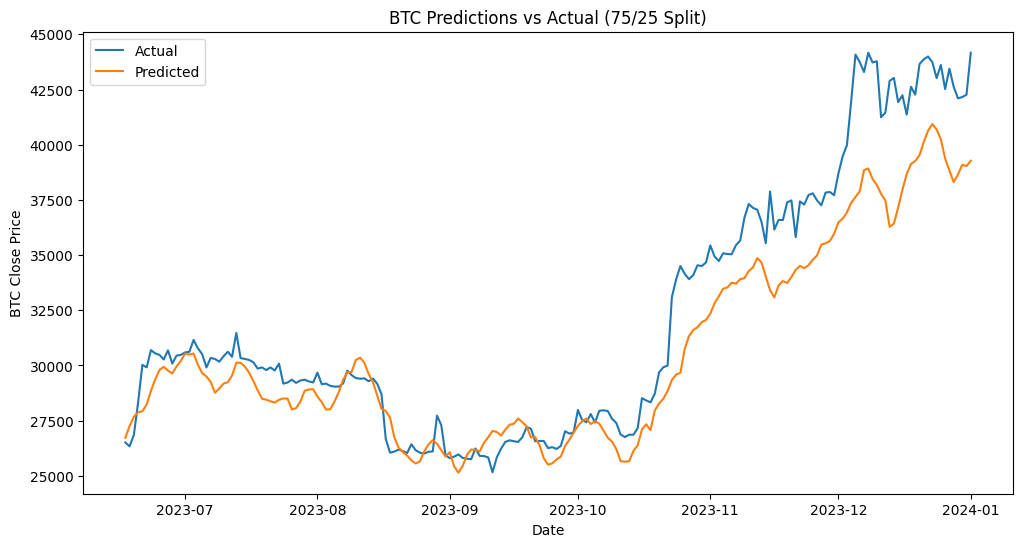

In [51]:
plt.figure(figsize=(12, 6))
plt.plot(btc_q3_df_plot["Actual"], label="Actual")
plt.plot(btc_q3_df_plot["Predicted"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("BTC Close Price")
plt.title("BTC Predictions vs Actual (75/25 Split)")
plt.legend()
plt.show()

# Fine tuning models using Optuna

In [54]:
# pip install optuna

In [55]:
import optuna

c:\Users\tharu\anaconda3\envs\Streamlit\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## model tuning 
(Base model with the best accuracy)

In [56]:
from sklearn.model_selection import train_test_split

X_train_tune, X_val_tune, y_train_tune, y_val_tune = train_test_split(
    X_train_seq,
    y_train_seq,
    test_size=0.2,
    shuffle=False
)

In [57]:
import torch
import numpy as np

def objective(trial):

    # Hyperparameters to tune
    hidden_size = trial.suggest_int("hidden_size", 32, 128)
    num_layers = trial.suggest_int("num_layers", 1, 3)
    lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    # Get input size
    input_size = X_train_tune.shape[2]

    # Create model
    model = BiLSTM(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers
    )

    # Train model
    model = train_model(
        model,
        X_train_tune,
        y_train_tune,
        epochs=30,
        batch_size=batch_size,
        lr=lr
    )

    # Validation prediction
    preds = predict_model(model, X_val_tune)

    # Calculate validation MSE
    val_loss = np.mean((preds.flatten() - y_val_tune) ** 2)

    return val_loss

In [58]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10)

[I 2026-03-17 13:45:19,942] A new study created in memory with name: no-name-e8c2427c-7bd6-43f7-a9c8-1c80639f0600
C:\Users\tharu\AppData\Local\Temp\ipykernel_6108\3165717294.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)


Epoch [10/30], Loss: 0.004936
Epoch [20/30], Loss: 0.002489


[I 2026-03-17 13:45:28,448] Trial 0 finished with value: 0.005698185597691346 and parameters: {'hidden_size': 96, 'num_layers': 1, 'lr': 0.005134729561342891, 'batch_size': 64}. Best is trial 0 with value: 0.005698185597691346.


Epoch [30/30], Loss: 0.006903
Epoch [10/30], Loss: 0.009938
Epoch [20/30], Loss: 0.002264


[I 2026-03-17 13:45:37,672] Trial 1 finished with value: 0.002634383798372713 and parameters: {'hidden_size': 114, 'num_layers': 1, 'lr': 0.0077324635062240125, 'batch_size': 64}. Best is trial 1 with value: 0.002634383798372713.


...

Epoch [30/30], Loss: 0.002474
Epoch [10/30], Loss: 0.003791
Epoch [20/30], Loss: 0.001704


[I 2026-03-17 13:48:13,411] Trial 8 finished with value: 0.0008218550093330353 and parameters: {'hidden_size': 47, 'num_layers': 2, 'lr': 0.0005352225410251934, 'batch_size': 32}. Best is trial 4 with value: 0.00022240459929033434.


Epoch [30/30], Loss: 0.002807
Epoch [10/30], Loss: 0.002846
Epoch [20/30], Loss: 0.007031


[I 2026-03-17 13:48:41,944] Trial 9 finished with value: 0.0003001107398425442 and parameters: {'hidden_size': 35, 'num_layers': 3, 'lr': 0.0008441295664940976, 'batch_size': 16}. Best is trial 4 with value: 0.00022240459929033434.


Epoch [30/30], Loss: 0.003121


In [59]:
print(study.best_params)

{'hidden_size': 78, 'num_layers': 2, 'lr': 0.0007451964123638622, 'batch_size': 32}


In [60]:
import optuna.visualization as vis

vis.plot_optimization_history(study)

In [61]:
vis.plot_param_importances(study)

In [62]:
import optuna.visualization as vis

vis.plot_parallel_coordinate(study)

## Testing the parameters

In [63]:
# Best parameters from Optuna
best_params = study.best_params

# Get input size
input_size = X_train_seq.shape[2]

# Create final tuned model
model_tuned = BiLSTM(
    input_size=input_size,
    hidden_size=best_params["hidden_size"],
    num_layers=best_params["num_layers"]
)

# Train final model on full training data
model_tuned = train_model(
    model_tuned,
    X_train_seq,
    y_train_seq,
    epochs=50,
    batch_size=best_params["batch_size"],
    lr=best_params["lr"]
)

c:\Users\tharu\anaconda3\envs\Streamlit\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning:

Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.



Epoch [10/50], Loss: 0.002599
Epoch [20/50], Loss: 0.002375
Epoch [30/50], Loss: 0.001867
Epoch [40/50], Loss: 0.001390
Epoch [50/50], Loss: 0.000956


In [64]:
btc_preds_tuned = predict_model(model_tuned, X_test_seq)
btc_preds_tuned[:10]

array([[0.60837305],
       [0.60237634],
       [0.6058439 ],
       [0.6013967 ],
       [0.5912455 ],
       [0.57302856],
       [0.565192  ],
       [0.57110626],
       [0.5652892 ],
       [0.55580974]], dtype=float32)

In [65]:
btc_preds_tuned_actual = y_scaler.inverse_transform(btc_preds_tuned.reshape(-1,1))

In [66]:
btc_y_test_actual = y_scaler.inverse_transform(y_test_seq.reshape(-1,1))

In [67]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(btc_y_test_actual, btc_preds_tuned_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(btc_y_test_actual, btc_preds_tuned_actual)
r2 = r2_score(btc_y_test_actual, btc_preds_tuned_actual)
mape = np.mean(np.abs((btc_y_test_actual - btc_preds_tuned_actual) / btc_y_test_actual)) * 100

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MSE: 8649443.52
RMSE: 2940.99
MAE: 2147.98
R2 Score: 0.9308
MAPE: 7.26%


# Saving the best performed model 

In [69]:
torch.save(model,"BTC_final_model.pth")